# Section 2 — L'Oracle OR-Tools

**Fichier source** : `oracle.py`

---

## Pourquoi un oracle ?

Notre modèle apprend **par imitation** : il observe des solutions optimales et apprend à reproduire les mêmes décisions. Pour générer ces solutions de référence, on utilise **OR-Tools**, le solveur de recherche opérationnelle de Google.

OR-Tools n'est pas rapide (quelques secondes par instance), mais il trouve des solutions **quasi-optimales** garanties. C'est lui qui génère les **labels** sur lesquels le modèle sera entraîné.

```
Instance VRPTW  →  Oracle OR-Tools  →  Solution optimale  →  Labels d'entraînement
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time

from preprocess import generate_instance
from oracle import resoudre_instance

SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)
print(f"Instance prête : n={N}, seed={SEED}, {instance['n_vehicles']} véhicules")

Instance prête : n=10, seed=42, 3 véhicules


## 1. Modélisation du problème

OR-Tools fonctionne avec des entiers. On commence par **discrétiser** toutes les valeurs continues :

```python
SCALE = 10   # précision : 0.1 minute

dist_int = (dist * vitesse * SCALE).astype(int64)  # distances → temps entiers
tw_int   = (time_windows * SCALE).astype(int64)    # fenêtres → entiers
svc_int  = (service_times * SCALE).astype(int64)   # services → entiers
dem_int  = demands.astype(int64)                   # demandes (déjà entières)
```

Ensuite on crée le **RoutingModel** avec :
- `n+1` nœuds (dépôt + clients)
- `K` véhicules
- Le dépôt comme point de départ/arrivée pour tous les véhicules

In [2]:
SCALE = 10
n = instance['n']
K = instance['n_vehicles']

dist_int = (instance['dist'] * instance['vitesse'] * SCALE).astype(np.int64)
tw_int   = (instance['time_windows'] * SCALE).astype(np.int64)
svc_int  = (instance['service_times'] * SCALE).astype(np.int64)
dem_int  = instance['demands'].astype(np.int64)

print(f"Nœuds dans le modèle : {n+1}  (0=dépôt, 1..{n}=clients)")
print(f"Véhicules : {K}")
print(f"Horizon (entier) : {int(instance['horizon'] * SCALE)} unités")
print(f"\nExemple dist_int[0,1] = {dist_int[0,1]}  ← trajet dépôt→client1 = {dist_int[0,1]/SCALE:.1f} min")
print(f"Exemple tw_int[1]    = {tw_int[1]}  ← fenêtre client1 = [{tw_int[1,0]/SCALE:.1f}, {tw_int[1,1]/SCALE:.1f}] min")

Nœuds dans le modèle : 11  (0=dépôt, 1..10=clients)
Véhicules : 3
Horizon (entier) : 4800 unités

Exemple dist_int[0,1] = 168  ← trajet dépôt→client1 = 16.8 min
Exemple tw_int[1]    = [1610 2452]  ← fenêtre client1 = [161.0, 245.2] min


## 2. Callbacks de coût et contraintes

OR-Tools fonctionne avec des **callbacks** — des fonctions appelées à chaque fois qu'il évalue un arc ou un nœud :

```python
# Callback 1 : coût d'un arc i→j (distance)
def dist_cb(i, j):
    return dist_int[node(i), node(j)]

# Callback 2 : temps de transit i→j (trajet + service en i)
def time_cb(i, j):
    return dist_int[node(i), node(j)] + svc_int[node(i)]

# Callback 3 : demande du nœud i (unaire)
def dem_cb(i):
    return dem_int[node(i)]
```

À partir de ces callbacks, on ajoute deux **dimensions** au modèle :
- **Dimension Temps** : cumule les temps de transit, force le respect des `[a_i, b_i]`
- **Dimension Capacité** : cumule les demandes, force le respect de `Q`

Les clients sont déclarés **optionnels** avec une pénalité très élevée — OR-Tools peut les ignorer si nécessaire, mais il est fortement incité à tous les servir.

In [3]:
# Illustration : vérification manuelle d'une contrainte de temps
# Si le véhicule part du dépôt et va au client 1, arrive-t-il à temps ?

client = 1
trajet_min    = instance['durees'][0, client]          # temps trajet dépôt → client
service       = instance['service_times'][client]      # durée service chez client
a_i, b_i      = instance['time_windows'][client]
arrivee       = max(trajet_min, a_i)                   # attente si arrivée avant ouverture
fin_service   = arrivee + service

print(f"=== Contrainte de temps : dépôt → client {client} ===")
print(f"Temps de trajet        : {trajet_min:.1f} min")
print(f"Fenêtre temporelle     : [{a_i:.1f}, {b_i:.1f}] min")
print(f"Arrivée estimée        : {trajet_min:.1f} min  {'(attente)' if trajet_min < a_i else ''}")
print(f"Début de service réel  : {arrivee:.1f} min")
print(f"Fin de service         : {fin_service:.1f} min")
print(f"Respect TW             : {'✓ OUI' if fin_service <= b_i else '✗ NON'}")

=== Contrainte de temps : dépôt → client 1 ===
Temps de trajet        : 16.8 min
Fenêtre temporelle     : [161.0, 245.2] min
Arrivée estimée        : 16.8 min  (attente)
Début de service réel  : 161.0 min
Fin de service         : 167.9 min
Respect TW             : ✓ OUI


## 3. Stratégie de recherche

OR-Tools utilise une approche en **deux phases** :

### Phase 1 — Solution initiale : PATH_CHEAPEST_ARC
Construit une première solution greedy : à chaque étape, choisit l'arc non encore assigné de coût minimal. Rapide mais pas optimal.

### Phase 2 — Amélioration : Guided Local Search (GLS)
Explore le voisinage de la solution courante (échanges de clients entre routes, inversions de sous-séquences...) et accepte des dégradations temporaires pour s'échapper des minima locaux. Continue jusqu'à `time_limit_s`.

```python
params.first_solution_strategy = PATH_CHEAPEST_ARC
params.local_search_metaheuristic = GUIDED_LOCAL_SEARCH
params.time_limit.seconds = 5
```

> **Compromis** : plus on donne de temps, meilleure est la solution. Pour n=10, 3s suffit. Pour n=50, on utilise 10s.

In [4]:
print("Résolution en cours...")
t0  = time.time()
sol = resoudre_instance(instance, time_limit_s=5.0)
dt  = time.time() - t0

print(f"\nTemps de résolution : {dt:.2f}s")
print(f"Faisable            : {sol['faisable']}")
print(f"Clients servis      : {sol['n_clients_servis']}/{N}")
print(f"Coût total          : {sol['cout']:.2f} unités de distance")
print(f"\nTournées :")
for i, route in enumerate(sol['tournees'], 1):
    if route:
        chemin = [0] + route + [0]
        cout_r = sum(instance['dist'][chemin[k], chemin[k+1]] for k in range(len(chemin)-1))
        print(f"  Véhicule {i} : {chemin}  (coût={cout_r:.1f})")

Résolution en cours...

Temps de résolution : 5.06s
Faisable            : True
Clients servis      : 10/10
Coût total          : 381.63 unités de distance

Tournées :
  Véhicule 1 : [0, 7, 6, 3, 5, 0]  (coût=182.8)
  Véhicule 2 : [0, 1, 10, 2, 4, 0]  (coût=107.3)
  Véhicule 3 : [0, 8, 9, 0]  (coût=91.6)


## 4. Structure de la solution retournée

`resoudre_instance()` retourne un dictionnaire :

```python
{
    'tournees'          : [[3, 1, 7], [4, 6], [2, 5, 8, 9, 10]],  # clients par véhicule
    'cout'              : 423.7,       # distance euclidienne totale (pas les durées)
    'aretes_sol'        : {(0,3), (1,3), (1,7), ...},  # arêtes utilisées
    'n_clients_servis'  : 10,
    'faisable'          : True,
}
```

**Important** : les `tournees` ne contiennent **pas le dépôt** — seulement les indices clients. Le dépôt est implicite au début et à la fin de chaque route.

In [5]:
print("Structure de la solution :")
print(f"  tournees       : {sol['tournees']}")
print(f"  cout           : {sol['cout']:.2f}")
print(f"  n_clients_servis : {sol['n_clients_servis']}")
print(f"  faisable       : {sol['faisable']}")
print(f"  aretes_sol     : {sorted(sol['aretes_sol'])}")

# Vérification manuelle du coût
cout_manuel = 0.0
for route in sol['tournees']:
    if route:
        chemin = [0] + route + [0]
        for a, b in zip(chemin[:-1], chemin[1:]):
            cout_manuel += instance['dist'][a, b]
print(f"\nVérification coût manuel : {cout_manuel:.2f}  (= {sol['cout']:.2f} ✓)")

Structure de la solution :
  tournees       : [[7, 6, 3, 5], [1, 10, 2, 4], [8, 9]]
  cout           : 381.63
  n_clients_servis : 10
  faisable       : True
  aretes_sol     : [(0, 1), (0, 4), (0, 5), (0, 7), (0, 8), (0, 9), (1, 10), (2, 4), (2, 10), (3, 5), (3, 6), (6, 7), (8, 9)]

Vérification coût manuel : 381.63  (= 381.63 ✓)


## 5. Visualisation de la solution oracle

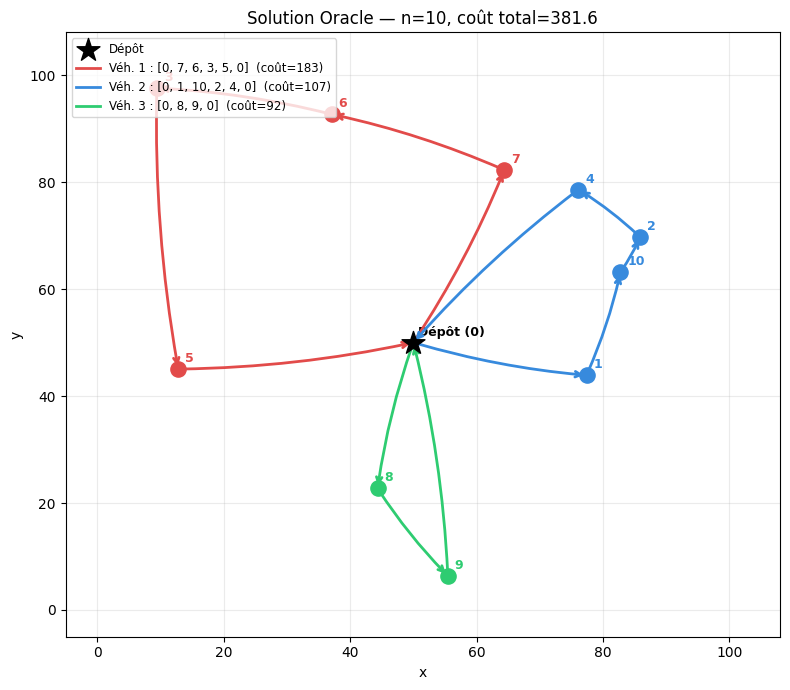

In [6]:
coords  = instance['coords']
palette = ['#E24B4A', '#378ADD', '#2ECC71', '#F59B00', '#9B59B6']

fig, ax = plt.subplots(figsize=(8, 7))

# Dépôt
ax.scatter(coords[0, 0], coords[0, 1], c='black', s=300,
           marker='*', zorder=5, label='Dépôt')
ax.annotate('Dépôt (0)', xy=coords[0], xytext=(3, 5),
            textcoords='offset points', fontsize=9, fontweight='bold')

# Routes
for v_idx, route in enumerate(sol['tournees']):
    if not route:
        continue
    color  = palette[v_idx % len(palette)]
    chemin = [0] + route + [0]
    cout_r = sum(instance['dist'][chemin[k], chemin[k+1]] for k in range(len(chemin)-1))

    # Tracer les arcs
    for k in range(len(chemin) - 1):
        a, b = chemin[k], chemin[k+1]
        ax.annotate('', xy=coords[b], xytext=coords[a],
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=2, connectionstyle='arc3,rad=0.05'))

    # Clients de cette route
    xs = coords[route, 0]
    ys = coords[route, 1]
    ax.scatter(xs, ys, c=color, s=120, zorder=4)
    for c_idx in route:
        ax.annotate(f'{c_idx}', xy=coords[c_idx], xytext=(5, 5),
                    textcoords='offset points', fontsize=9, color=color, fontweight='bold')

    # Légende
    ax.plot([], [], color=color, linewidth=2,
            label=f'Véh. {v_idx+1} : {[0]+route+[0]}  (coût={cout_r:.0f})')

ax.set_title(f'Solution Oracle — n={N}, coût total={sol["cout"]:.1f}', fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=8.5, loc='upper left')
ax.set_xlim(-5, 108)
ax.set_ylim(-5, 108)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Qualité et temps de résolution selon n

L'oracle devient plus lent et moins optimal quand n augmente. C'est précisément là où le modèle deep learning apporte de la valeur : **il est des milliers de fois plus rapide** à l'inférence.

In [7]:
print(f"{'n':>5} | {'Temps oracle':>13} | {'Faisable':>9} | {'Coût':>8} | {'Clients servis':>15}")
print("-" * 58)

for n_test, tl in [(10, 3.0), (20, 5.0), (50, 10.0)]:
    inst = generate_instance(n=n_test, seed=SEED)
    t0   = time.time()
    s    = resoudre_instance(inst, time_limit_s=tl)
    dt   = time.time() - t0
    if s:
        print(f"{n_test:>5} | {dt:>11.2f}s | {'Oui' if s['faisable'] else 'Non':>9} | {s['cout']:>8.1f} | {s['n_clients_servis']:>6}/{n_test}")
    else:
        print(f"{n_test:>5} | {dt:>11.2f}s | {'Aucune solution':>9}")

    n |  Temps oracle |  Faisable |     Coût |  Clients servis
----------------------------------------------------------
   10 |        3.00s |       Oui |    381.6 |     10/10
   20 |        5.00s |       Oui |    610.2 |     20/20
   50 |       10.00s |       Oui |    858.8 |     50/50


## Récapitulatif

```
generate_instance(n, seed)
        ↓
resoudre_instance(instance, time_limit_s)
        ↓
{
  tournees : [[clients_veh1], [clients_veh2], ...]
  cout     : distance totale (référence = 100%)
  faisable : True si tous les clients servis
}
```

Ces **tournées oracle** sont la matière première de la Section 3 : `build_decision_dataset.py` va les rejouer pas à pas pour extraire les décisions individuelles sur lesquelles le modèle sera entraîné.